General EDA

In [2]:
%run build_master_dataset.py

Rows: 2626
Seasons: 1985–2025

Null counts:
season                0
team_id               0
team_name             0
seed                  0
seed_region           0
conference            0
reg_season_wins       0
reg_season_losses     0
reg_season_win_pct    0
reached_playin        0
won_playin            0
reached_r64           0
reached_r32           0
reached_s16           0
reached_e8            0
reached_f4            0
reached_f2            0
won_championship      0
payout_pct            0
dtype: int64

2023 UConn:
Empty DataFrame
Columns: [season, team_id, team_name, seed, seed_region, conference, reg_season_wins, reg_season_losses, reg_season_win_pct, reached_playin, won_playin, reached_r64, reached_r32, reached_s16, reached_e8, reached_f4, reached_f2, won_championship, payout_pct]
Index: []

Saved to /Users/harrywang/Desktop/Data Projects/march-madness-calcutta/data/master_tourney_dataset.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/master_tourney_dataset.csv")

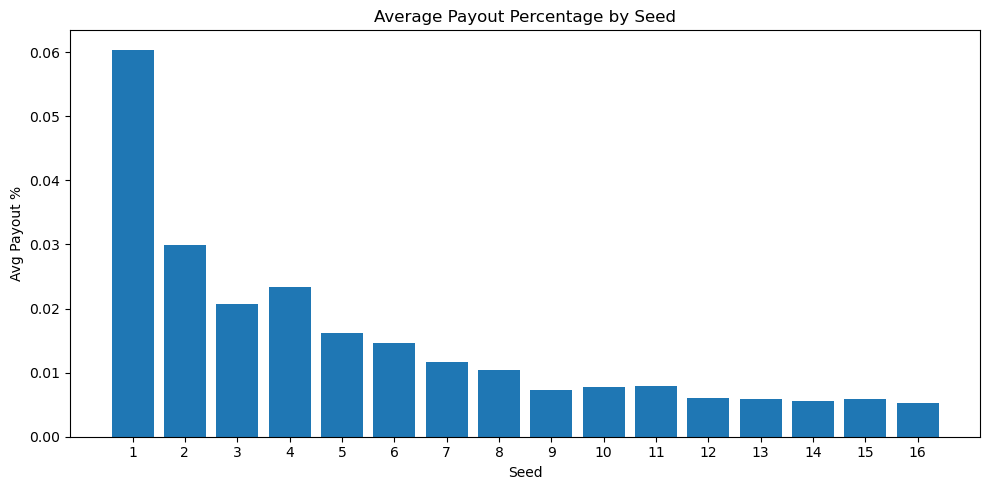

In [4]:
avg_payout = df.groupby("seed")["payout_pct"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_payout.index, avg_payout.values)
ax.set_xlabel("Seed")
ax.set_ylabel("Avg Payout %")
ax.set_title("Average Payout Percentage by Seed")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()

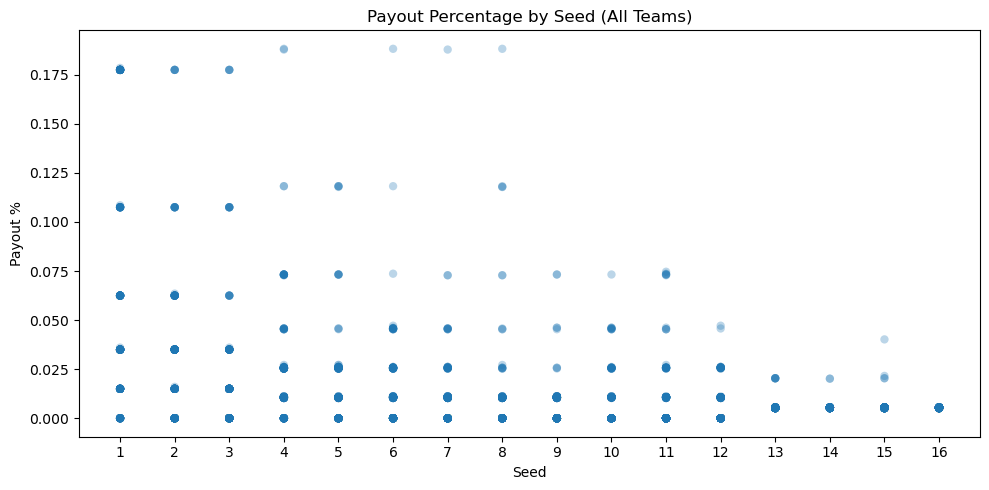

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["seed"], df["payout_pct"], alpha=0.3, edgecolors="none")
ax.set_xlabel("Seed")
ax.set_ylabel("Payout %")
ax.set_title("Payout Percentage by Seed (All Teams)")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()

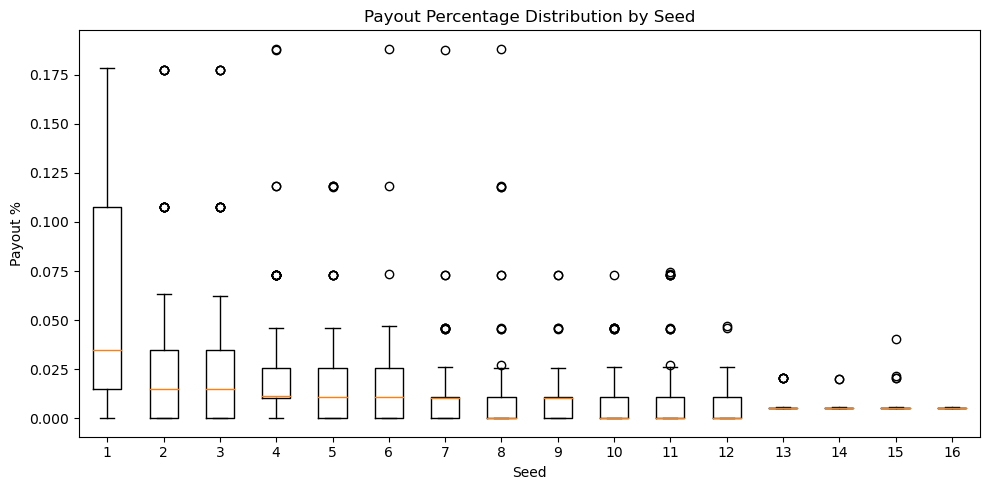

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df[df["seed"] == s]["payout_pct"].values for s in range(1, 17)]
ax.boxplot(data, labels=range(1, 17))
ax.set_xlabel("Seed")
ax.set_ylabel("Payout %")
ax.set_title("Payout Percentage Distribution by Seed")
plt.tight_layout()
plt.show()

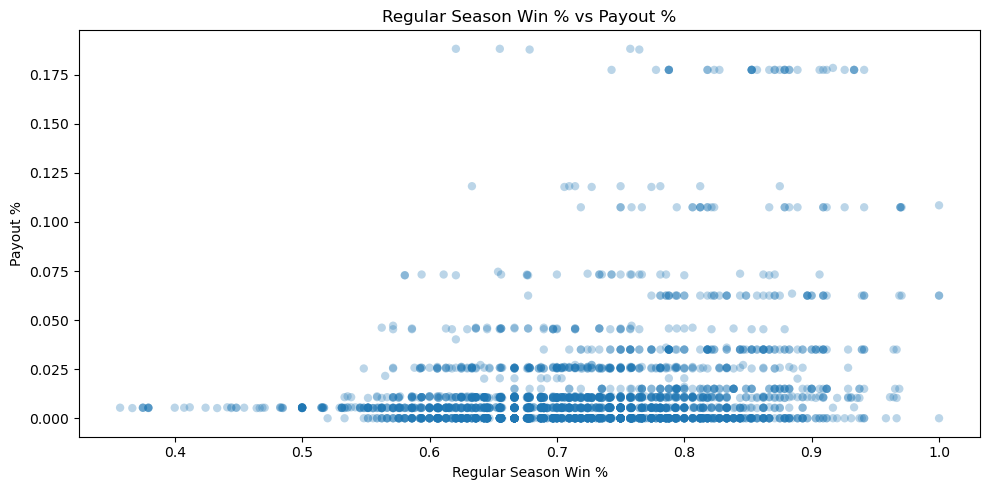

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["reg_season_win_pct"], df["payout_pct"], alpha=0.3, edgecolors="none")
ax.set_xlabel("Regular Season Win %")
ax.set_ylabel("Payout %")
ax.set_title("Regular Season Win % vs Payout %")
plt.tight_layout()
plt.show()

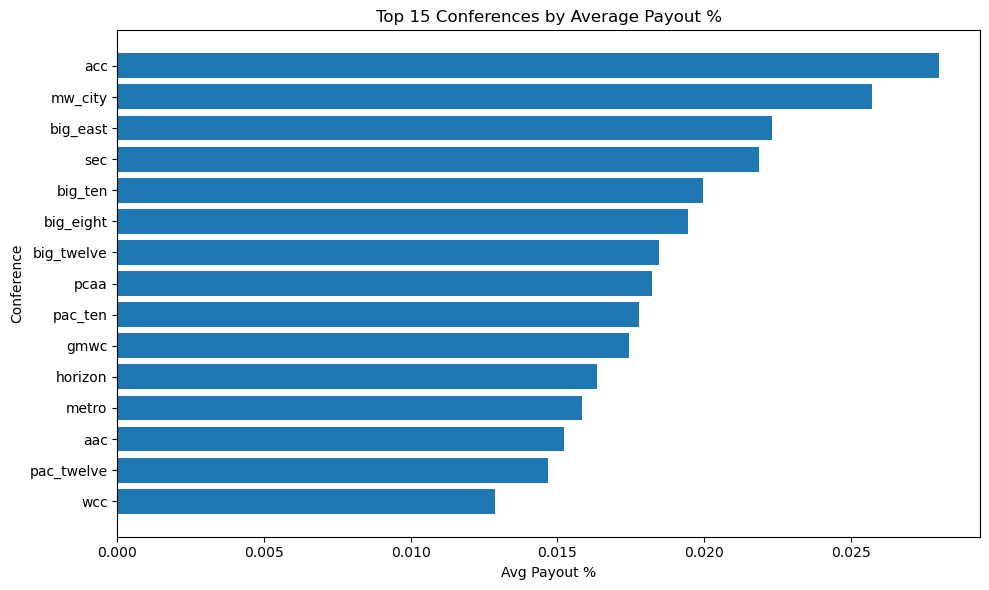

In [8]:
conf_avg = df.groupby("conference")["payout_pct"].mean().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(conf_avg.index, conf_avg.values)
ax.set_xlabel("Avg Payout %")
ax.set_ylabel("Conference")
ax.set_title("Top 15 Conferences by Average Payout %")
plt.tight_layout()
plt.show()

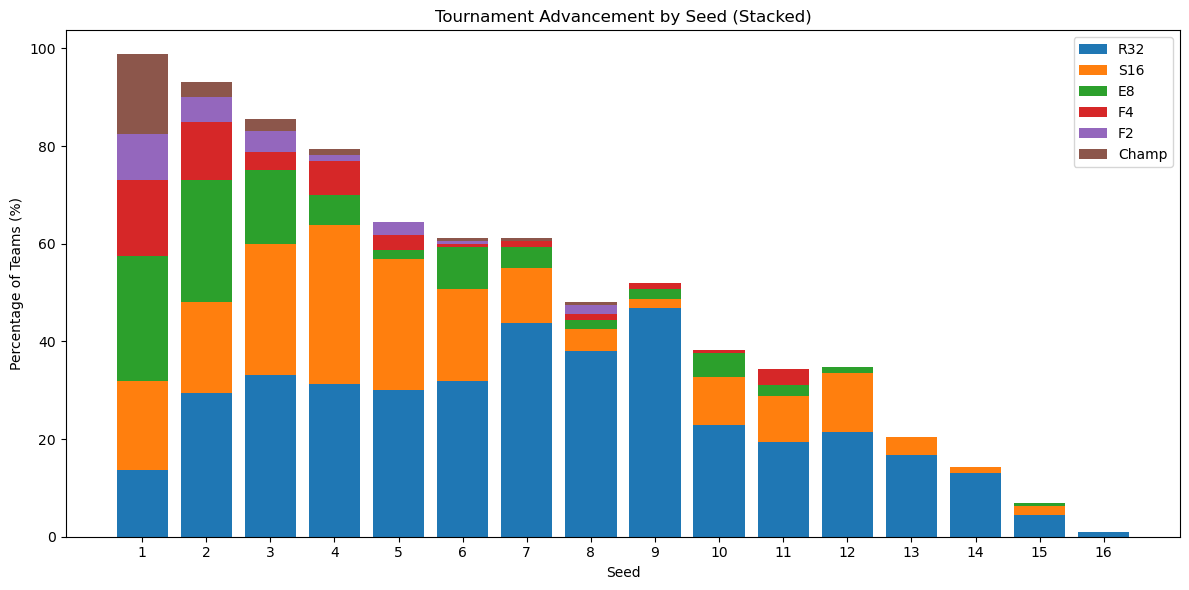

In [9]:
import numpy as np

rounds = ["reached_r32", "reached_s16", "reached_e8", "reached_f4", "reached_f2", "won_championship"]
round_labels = ["R32", "S16", "E8", "F4", "F2", "Champ"]

seeds = range(1, 17)
props = pd.DataFrame(index=seeds, columns=round_labels, dtype=float)
for s in seeds:
    subset = df[df["seed"] == s]
    for col, label in zip(rounds, round_labels):
        props.loc[s, label] = subset[col].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(16)
for i, label in enumerate(round_labels):
    if i == 0:
        vals = props[label].values
    else:
        vals = props[label].values
    # Each bar segment = % reaching this round minus % reaching next round
    if i < len(round_labels) - 1:
        segment = props[label].values - props[round_labels[i + 1]].values
    else:
        segment = props[label].values
    ax.bar(list(seeds), segment, bottom=bottom, label=label)
    bottom += segment

ax.set_xlabel("Seed")
ax.set_ylabel("Percentage of Teams (%)")
ax.set_title("Tournament Advancement by Seed (Stacked)")
ax.set_xticks(list(seeds))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

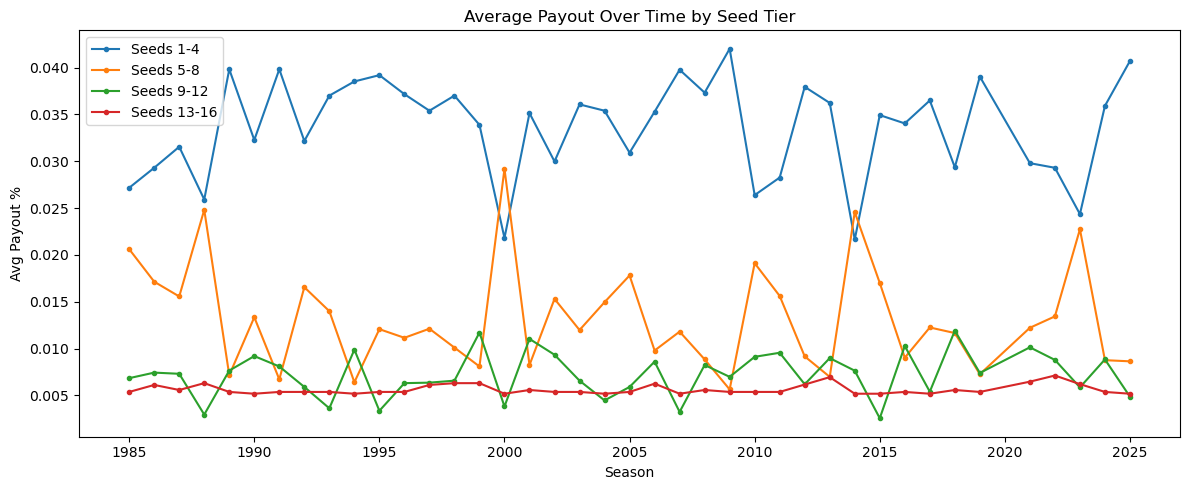

In [10]:
bins = [(1, 4), (5, 8), (9, 12), (13, 16)]
tier_labels = ["1-4", "5-8", "9-12", "13-16"]

fig, ax = plt.subplots(figsize=(12, 5))
for (lo, hi), label in zip(bins, tier_labels):
    tier = df[(df["seed"] >= lo) & (df["seed"] <= hi)]
    tier_avg = tier.groupby("season")["payout_pct"].mean()
    ax.plot(tier_avg.index, tier_avg.values, label=f"Seeds {label}", marker="o", markersize=3)

ax.set_xlabel("Season")
ax.set_ylabel("Avg Payout %")
ax.set_title("Average Payout Over Time by Seed Tier")
ax.legend()
plt.tight_layout()
plt.show()

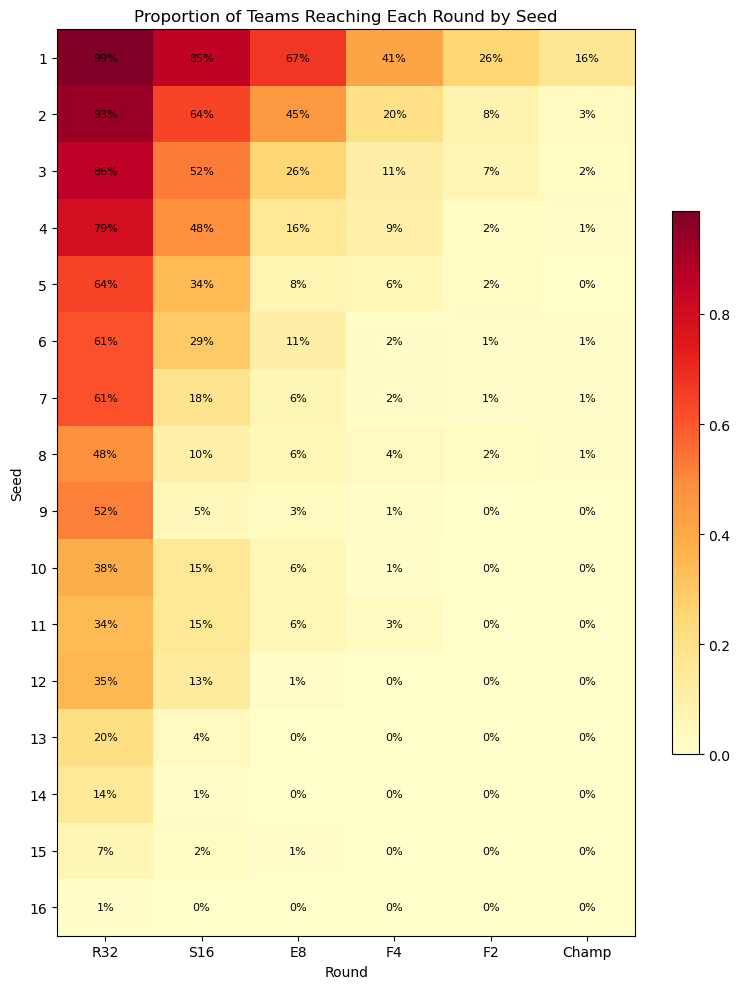

In [11]:
rounds = ["reached_r32", "reached_s16", "reached_e8", "reached_f4", "reached_f2", "won_championship"]
round_labels = ["R32", "S16", "E8", "F4", "F2", "Champ"]

heatmap = np.zeros((16, len(rounds)))
for i, s in enumerate(range(1, 17)):
    subset = df[df["seed"] == s]
    for j, col in enumerate(rounds):
        heatmap[i, j] = subset[col].mean()

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap, cmap="YlOrRd", aspect="auto")
for i in range(16):
    for j in range(len(rounds)):
        ax.text(j, i, f"{heatmap[i, j]:.0%}", ha="center", va="center", fontsize=8)

ax.set_xticks(range(len(round_labels)))
ax.set_xticklabels(round_labels)
ax.set_yticks(range(16))
ax.set_yticklabels(range(1, 17))
ax.set_xlabel("Round")
ax.set_ylabel("Seed")
ax.set_title("Proportion of Teams Reaching Each Round by Seed")
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

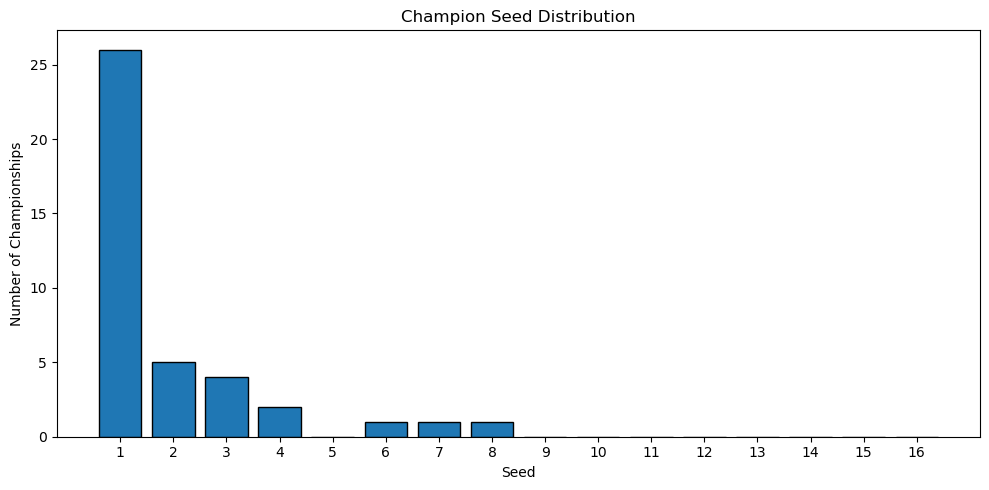

In [12]:
champs = df[df["won_championship"] == 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(champs["seed"], bins=range(1, 18), align="left", edgecolor="black", rwidth=0.8)
ax.set_xlabel("Seed")
ax.set_ylabel("Number of Championships")
ax.set_title("Champion Seed Distribution")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()